In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Cinética de Procesos (Sesión 06)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 3 Modelo de partícula decreciente

## 3.1 Descripción del modelo

### 3.1.1 Descripción general

En este modelo, una partícula sólida de material $\mathrm{B}$, con radio inicial $R$ reacciona con un fluido. Conforme la reacción procede y el reactivo $\mathrm{B}$ se consume, el radio de la partícula, $r_c$, disminuye. A lo largo de la reacción los productos de reacción se desprenden de la partícula.


**Aplicaciones posibles:**

- Reacciones de disolución.
- Ataque químico.
- Corrosión de superficies no pasivables.

### 3.1.2 Conversión

La conversión se relaciona directamente con el tamaño de la partícula, $R$ con respecto a su tamaño original $R_0$.

$$X_{\mathrm{B}} = 1 - \left(\frac{R}{R_0}\right)^3

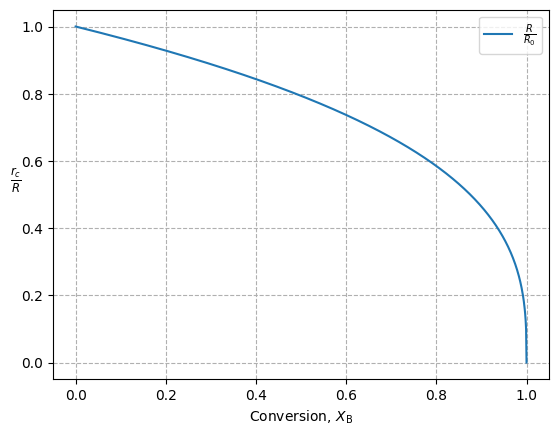

In [12]:
fig, ax = plt.subplots()
xB = np.linspace(0, 1, 1001)
r = np.power(1-xB, 1/3)
ax.plot(xB, r, label=r"$\frac{R}{R_0}$")
ax.set_xlabel(r"Conversion, $X_{\mathrm{B}}$")
ax.set_ylabel(r"$\frac{r_c}{R}$", rotation=0, fontsize=12)
ax.legend()
ax.grid(ls='--')
plt.show()

### 3.1.3 Fenomenología

La fenomenología del modelo consta de 3 etapas que incluyen los procesos difusivos de reactivos y productos en capa límite, y la reacción que ocurre en la superficie de la partícula.

- **Etapa 1:** Difusión del reactivo $\mathrm{A}$ a través de la capa límite formada alrededor de la superficie de la partícula, hacia el interior.

- **Etapa 2:** Reacción de $\mathrm{A}$ con $\mathrm{B}$ en la superficie de reacción.

- **Etapa 3:** Difusión de los productos de reacción a través de la capa límite formada alrededor de la superficie de la partícula, hacia el exterior.

Cada una de estas etapas ocurre de manera simultanea, y se puede considerar conceptualmente como un conjunto de resistencias en serie. Entonces, el tiempo requerido para que ocurra un cierto nivel de conversión es igual a la suma de las contribuciones de cada etapa:

$$t_{\text{total}} = \underbrace{t_{\text{capa límite}}}_{\text{Etapas: 1, 3}} + \underbrace{t_{\text{reacción}}}_{\text{Etapa 2}}$$

De igual forma, el tiempo característico para lograr la conversión total es:

$$\tau_{\text{total}} = \underbrace{\tau_{\text{capa límite}}}_{\text{Etapas: 1, 3}} + \underbrace{\tau_{\text{reacción}}}_{\text{Etapa 2}}$$

## 3.2 Ecuaciones del modelo

### 3.2.1 Ecuación diferencial con tiempos característicos

**Ecuación general**

El modelo general considera la contribución de cada mecanismo (difusión de especies en la capa límite, y reacción en la superficie de reacción), como términos resistivos en una ecuación transitoria que describe el flujo molar de la especie $\mathrm{B}$ en la interfase entre el núcle decreciente y la capa de productos:


$$-\frac{1}{S_{\mathrm{ex}}} \frac{dN_\mathrm{B}}{dt} = \frac{\displaystyle b C_{\mathrm{A}}}{\displaystyle \underbrace{\frac{1}{k_{\mathrm{g}}}}_{\text{capa límite}} + \underbrace{\frac{1}{ k^{\prime \prime}}}_{\text{reacción}}}$$



**Ecuación en términos del radio de la partícula decreciente**

Para una geometría esférica, el volumen de la partícula decreciente y la superficie de la interfase estan dadas por:

$$V = \frac{4}{3} \pi R^3$$

$$S_{\mathrm{ex}} = 4\pi R^2$$

y el cambio diferencial de la cantidad de especie $\mathrm{B}$, $dN_{\mathrm{B}}$, está dado por:

$$dN_{\mathrm{B}} = \rho_{B} dV = \rho_{B} \cdot 4 \pi r^2 dR$$


La ecuación se puede entonces escribir en términos del radio de la partícula decreciente:

$$-\frac{dR}{dt} = \frac{\displaystyle \frac{b C_{\mathrm{A}}}{\rho_{B}}}{\displaystyle \underbrace{\frac{1}{k_{\mathrm{g}}}}_{\text{capa límite}} + \underbrace{\frac{1}{k^{\prime \prime}}}_{\text{reacción}}}$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$t$**: tiempo, $\mathrm{[s]}$.

- **$\tau$**: tiempo característico, $\mathrm{[s]}$.

- **$X_{\mathrm{B}}$**: conversión.

- **$\rho_{\mathrm{B}}$**: densidad molar del reactivo $\mathrm{B}$, $\mathrm{[mol.m^{-3}]}$.

- **$R$**: radio inicial de la partícula, $\mathrm{[m]}$.

- **$b$**: coeficiente estequiométrico de la reacción.

- **$k_{\mathrm{g}}$**: coeficiente de transferencia de masa entre fluido y partícula, $\mathrm{[m.s^{-1}]}$.

- **$k^{\prime \prime}$**: constante de reacción en la superficie (1er orden), $\mathrm{[m.s^{-1}]}$.

- **$C_{\mathrm{A}}$**: Concentración de $\mathrm{A}$, $\mathrm{mol.m^{-3}}$.

</div>

</details>

In [13]:
def shrinking_particle(t, R, R0, rhoB, b, cA, kg, kpp):
    r1 = 1/kg
    r2 = 1/kpp
    return -(b*cA/rhoB) / (r1 + r2)
def shrinking_particle_end(t, R, R0, rhoB, b, cA, kg, kpp):
    return R[0]
shrinking_particle_end.terminal=True

### 3.2.2 Expresiones Conversión-tiempo para partículas pequeñas (para distintas etapas limitantes)

Si se asume que un solo mecanismo es preponderante, i.e., es la étapa limitante, existen expresiones algebráicas individuales. Se considera que para partículas pequeñas:

$$k_{\mathrm{g}} \sim \frac{1}{d_p}$$



#### 3.2.2.1 Difusión en la capa límite

$$\frac{t}{\tau} = 1 - \left(1 - X_{\mathrm{B}} \right)^{\frac{2}{3}}$$

$$\tau = \frac{\rho_{\mathrm{B}} R_0}{2b k_{\mathrm{g}} C_{\mathrm{A,g}}} = \frac{\rho_{\mathrm{B}} R_0^2}{2b D_{e}C_{\mathrm{A,g}}}$$

$$k_{\mathrm{g}} = \frac{D_{e}}{R}$$

#### 3.2.2.2 Reacción química

$$\frac{t}{\tau} = 1 - \left( 1 - X_{\mathrm{B}}\right)^{\frac{1}{3}}$$

$$\tau = \frac{\rho_{B} R_{0}}{b k^{\prime \prime} C_{\mathrm{A,g}}}$$

### 3.2.3 Expresiones Conversión-tiempo para partículas grandes (para distintas etapas limitantes)

Si se asume que un solo mecanismo es preponderante, i.e., es la étapa limitante, existen expresiones algebráicas individuales. Se considera que para partículas grandes:

$$k_{\mathrm{g}} \sim \frac{\displaystyle u^{\frac{1}{2}}}{d_p^{\frac{1}{2}}}$$



#### 3.2.3.1 Difusión en la capa límite

$$\frac{t}{\tau} = 1 - \left(1 - X_{\mathrm{B}} \right)^{\frac{1}{2}}$$

$$\tau = (\text{const.}) \frac{R_{0}^{\frac{3}{2}}}{C_{\mathrm{A,g}}}$$



#### 3.2.3.2 Reacción química

$$\frac{t}{\tau} = 1 - \left( 1 - X_{\mathrm{B}}\right)^{\frac{1}{3}}$$

$$\tau = \frac{\rho_{B} R}{b k^{\prime \prime} C_{\mathrm{A,g}}}$$

## 3.3 Ejemplos

### 3.3.1 Implementación

In [14]:
def plot_shrinking_particle_model(R0, t_max, rhoB, b, cA, kg, kpp, ax=None):
    if ax == None:
        fig, ax = plt.subplot()

    ################################ Full model (ordinary differential equation)
    t_span = (0, t_max)
    ndt = 1001

    t_eval = np.linspace(t_span[0], t_span[1], ndt)
    sol = solve_ivp(
        shrinking_particle,
        t_span = t_span,
        y0 = (R,),
        args=(R, rhoB, b, cA, kg, kpp),
        t_eval = t_eval,
        events = shrinking_particle_end
    )
    tfull, rfull = sol.t, sol.y[0]

    # print-out time
    print(f"Characteristic time considering all mechanisms:")
    print(f"- full model              : {tfull[-1]:8.2f} s")


    # plot
    ax.plot(tfull, rfull, label='full model')
    ax.legend()
    ax.grid(ls='--')

### 3.3.2 Ejemplos

Characteristic time considering all mechanisms:
- full model              :    19.98 s


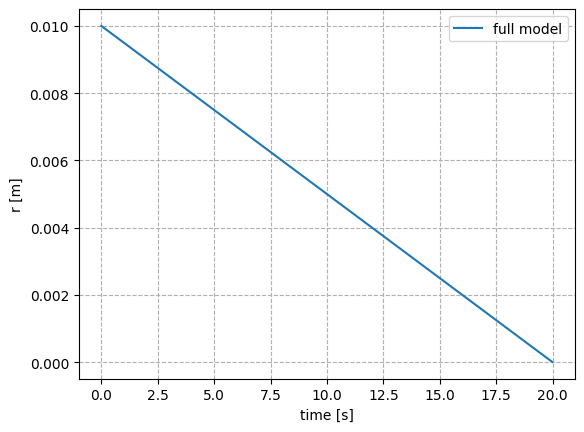

In [24]:
# parameters
R = 0.01 # m
tmax = 30 #[s]
rhoB = 1 #mol/m3
b = 1
cA = 1 # mol/m3
kg = 1e-3
kpp = 1e-3

fig, ax = plt.subplots()
plot_shrinking_particle_model(R, tmax, rhoB, b, cA, kg, kpp, ax=ax)
ax.set_xlabel("time [s]")
ax.set_ylabel("r [m]")
plt.show()

Characteristic time considering all mechanisms:
- full model              :     9.99 s


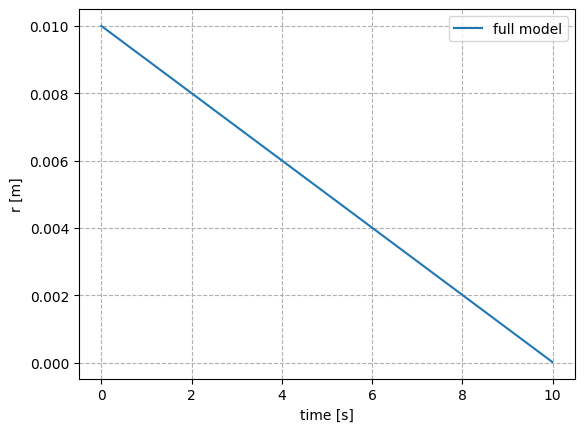

In [28]:
# parameters
R = 0.01 # m
tmax = 30 #[s]
rhoB = 1 #mol/m3
b = 1
cA = 1 # mol/m3
kg = 1e-3
kpp = 1

fig, ax = plt.subplots()
plot_shrinking_particle_model(R, tmax, rhoB, b, cA, kg, kpp, ax=ax)
ax.set_xlabel("time [s]")
ax.set_ylabel("r [m]")
plt.show()

Characteristic time considering all mechanisms:
- full model              :     9.99 s


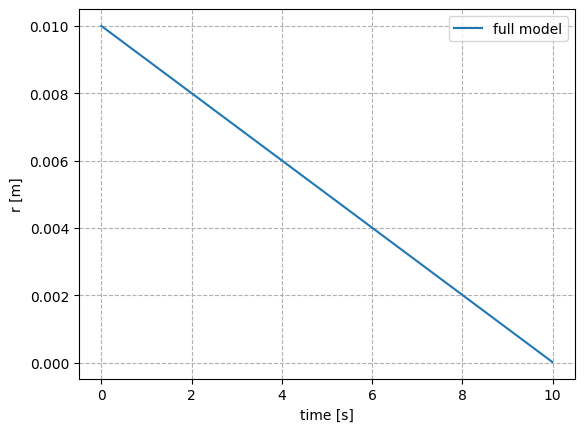

In [26]:
# parameters
R = 0.01 # m
tmax = 30 #[s]
rhoB = 1 #mol/m3
b = 1
cA = 1 # mol/m3
kg = 1
kpp = 1e-3

fig, ax = plt.subplots()
plot_shrinking_particle_model(R, tmax, rhoB, b, cA, kg, kpp, ax=ax)
ax.set_xlabel("time [s]")
ax.set_ylabel("r [m]")
plt.show()